In [1]:
# displays static in notebook
%matplotlib inline  
# displays interactive outside notebook
#%matplotlib   
# displays interactive in notebook
#%matplotlib notebook  

# to work correctly with numbers
import numpy as np

# plotting
import matplotlib.pyplot as plt
import matplotlib as mpl

# conversion between coordinate systems
import astropy.coordinates as coord
import astropy.units as u

#from astropy import units as u
from astropy.coordinates import SkyCoord

import os

# for making data catalogues that are easily uploaded to Javascript
import json

# for loading fits files
from astropy.io import fits


folder = ''

mpl.rcParams['font.family']='serif'
mpl.rcParams['font.size']=14

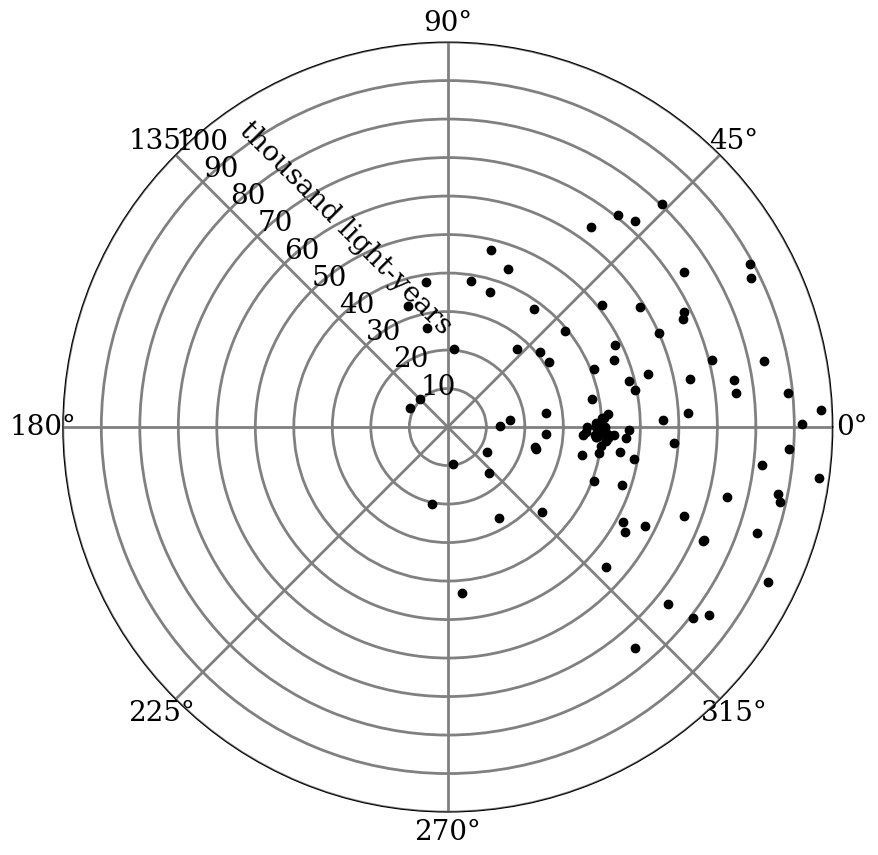

In [3]:
###################
##
## generate a distribution of globular clusters
## plot them in R, theta from a system offset from the center of the distribution

r_bulge = 1.5
n_bulge = 20
r_halo = 60.0
n_halo = 90
d_center = 40

X_bulge = np.random.normal(d_center,r_bulge,n_bulge)
Y_bulge = np.random.normal(0,r_bulge,n_bulge)
R_halo = np.random.uniform(0,r_halo,n_halo)
Theta_halo = np.random.uniform(0,360,n_halo)
X_halo = d_center + R_halo*np.cos(Theta_halo * np.pi / 180)
Y_halo = R_halo*np.sin(Theta_halo * np.pi / 180)

X = np.concatenate((X_bulge,X_halo),axis=0)
Y = np.concatenate((Y_bulge,Y_halo),axis=0)

#plt.plot(X,Y,'ko')

r = (X**2 + Y**2)**(0.5)
theta = np.arctan2(Y,X)

#r = [1000]
#theta = [0]

fig = plt.figure(figsize=(10,10))
ax = plt.subplot(111, projection='polar')
ax.plot(theta, r,'ko')
ax.set_rmax(100)
ax.set_rticks(np.arange(0,101,20))  # less radial ticks
# ax.set_rlabel_position(135)
ax.set_rgrids(np.arange(10,101,10), angle=135)
#ax.set_rmax(10)
#ax.set_rticks(np.arange(0,11,2))  # less radial ticks
#ax.set_rlabel_position(-22.5)  # get radial labels away from plotted line
plt.tick_params(axis='both', which='major', labelsize=20)
ax.grid(True)
ax.grid(linestyle='-', linewidth=2, color='gray')

#ax.set_title("Distances in thousands of light-years", fontsize=20, va='top', ha='left')
plt.annotate('thousand light-years',xy=(15, 35), xytext=(0,0), fontsize=20, textcoords='offset points', ha='center', va='bottom', rotation = -45)
#ax.annotate("this ok", xy=[np.pi/8,15], fontsize=20, rotation=np.rad2deg(np.pi/3))

plt.show()


34.882 -45.64 57.44 -52.61 46.7 True
9.453999999999999 -23.145999999999997 25.0 -67.78 27.88 True
9.453999999999999 -15.974 18.56 -59.38 22.29 True
35.86 -32.599999999999994 48.46 -42.27 34.36 True
6.193999999999999 -8.475999999999999 10.5 -53.84 20.63 True
11.735999999999999 -17.604 21.16 -56.31 22.04 True
10.106 -16.625999999999998 19.46 -58.71 22.32 True
19.56 -13.365999999999998 23.69 -34.35 14.43 True
6.52 -29.991999999999997 30.69 -77.74 35.23 True
10.758 -4.563999999999999 11.69 -22.99 14.96 True
22.168 -13.365999999999998 25.89 -31.09 13.66 True
0.326 -32.599999999999994 32.6 -89.43 40.88 True
6.846 -2.608 7.33 -20.85 18.34 True
40.098 -13.04 42.17 -18.01 19.95 True
24.775999999999996 -28.035999999999998 37.41 -48.53 28.04 True
34.882 -58.028 67.71 -58.99 58.86 True
20.864 -13.692 24.96 -33.27 14.3 True
29.014 -18.255999999999997 34.28 -32.18 18.69 True
52.486000000000004 -32.274 61.61 -31.59 42.39 True
-53.79 -261.126 266.61 -101.64 272.75 False
17.278 -5.867999999999999 18.25

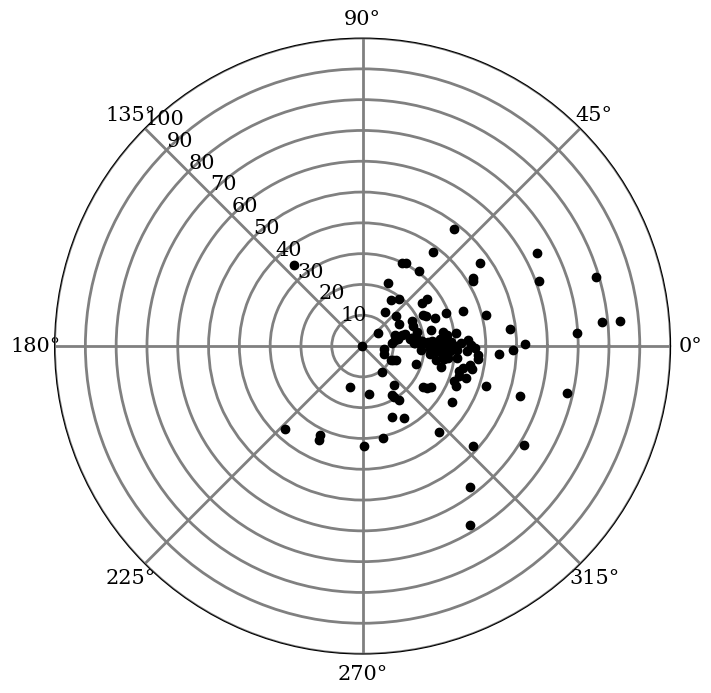

In [37]:
###################
##
## read the distribution of globular clusters in our galaxy
## plot them in R, theta from a system offset from the center of the distribution

#inFile = 'Dropbox/teaching/ASTR10B-2018-Fall/globular-clusters.txt'
#inFile = 'Dropbox/teaching/Teaching (archive)/Lecture Tutorials/MathewsG/Galaxy - size/globular-clusters.txt'
inFile = 'globular-clusters-XY-HEASARC.txt'
globularClusters = np.genfromtxt(inFile)

X = 3.26*globularClusters[:,0]
Y = 3.26*globularClusters[:,1]

#rCens = ((r*sin(theta*np.pi/180))**2 + (r*cos(theta*np.pi/180)-25)**2)**(0.5)
r = (X**2 + Y**2)**(0.5)
theta = np.arctan2(Y,X)*180.0/np.pi
xCen = 25.0
yCen = 0.0
rCen = ((X-xCen)*(X-xCen) + (Y-yCen)*(Y-yCen))**(0.5)
useGC = rCen < 60

for i in np.arange(len(X)):
    print(X[i],Y[i],np.round(r[i],2),np.round(theta[i],2),np.round(rCen[i],2), useGC[i])

    
#useGC = np.where(rCen < 50)
#useGC = np.where(rCen < 500)
rmax = 100


fig = plt.figure(figsize=(8,8))
ax = plt.subplot(111, projection='polar')
#ax.plot(theta * np.pi/180, r,'ko')
#ax.plot(theta[useGC] * np.pi/180, r[useGC],'ro')
ax.plot(theta[useGC] * np.pi/180, r[useGC],'ko')

#ax.set_rmax(rmax)
#ax.set_rmin(0)
#ax.set_rgrids(np.arange(10,rmax+1,10), angle=112.5)
ax.set_rmax(100)
ax.set_rgrids(np.arange(0,101,10), angle=135)
ax.set_rticks(np.arange(10,101,10))  # less radial ticks
plt.tick_params(axis='both', which='major', labelsize=15)
ax.grid(True)
ax.grid(linestyle='-', linewidth=2, color='gray')

#plt.annotate('thousand light-years',xy=(15.2, 35), xytext=(0,0), fontsize=20, textcoords='offset points', ha='center', va='bottom', rotation = -67.5)
#plt.annotate('thousand light-years',xy=(15.3, 25), xytext=(0,0), fontsize=20, textcoords='offset points', ha='center', va='bottom', rotation = -67.5)
#ax.set_title("Distances in thousands of light-years", fontsize=20, va='top', ha='left')
#ax.annotate("this ok", xy=[np.pi/8,15], fontsize=20, rotation=np.rad2deg(np.pi/3))

#plt.show()
plt.savefig("milky way globular clusters.jpg") #save as jpg


# ax.set_rlabel_position(135)
#ax.set_rticks(np.arange(10,201,20))  # less radial ticks
#ax.set_rmax(10)
#ax.set_rticks(np.arange(0,11,2))  # less radial ticks
#ax.set_rlabel_position(-22.5)  # get radial labels away from plotted line

#theta_hist = np.histogram(theta,bins=10*np.arange(37))
#plt.plot(10*np.arange(36)+5,theta_hist[0],'ko')
#plt.plot(theta,r,'ko')

#rCens_hist = np.histogram(rCen,bins=10*np.arange(21))
#plt.plot(10*np.arange(20)+5,rCens_hist[0],'ko')

#rCens_cumHist = np.cumsum(rCens_hist[0])
#plt.plot(10*np.arange(20)+5,1.0*rCens_cumHist / np.sum(rCens_hist[0]),'ko')

#plt.plot(theta,r,'ko')


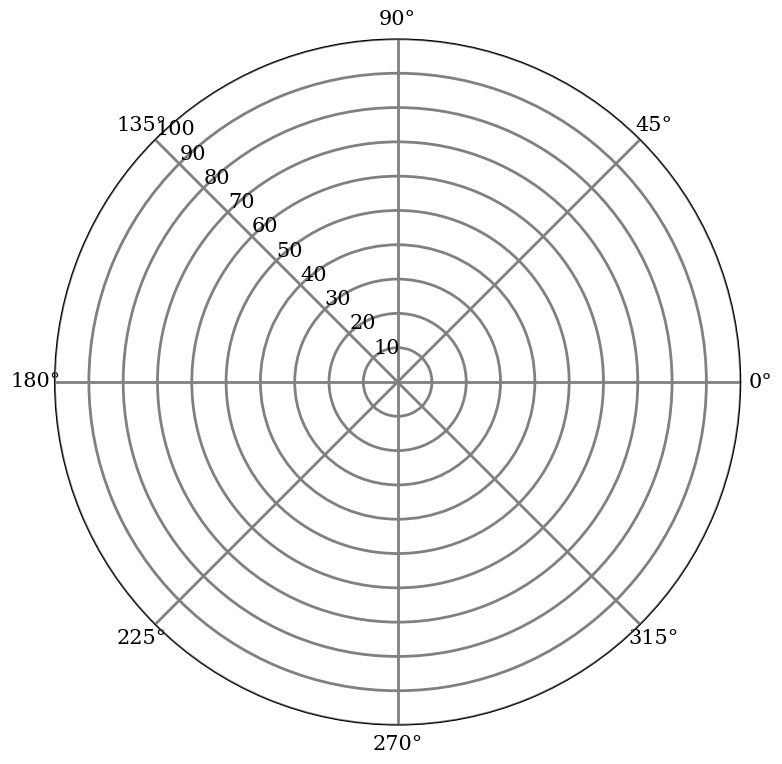

In [25]:
###################
##
## blank radial plot


fig = plt.figure(figsize=(8,8))
ax = plt.subplot(111, projection='polar')
#ax.plot([0],[0],'ko')
#plt.annotate('you',xy=(0, 0), xytext=(0,0), fontsize=20, textcoords='offset points', ha='center', va='bottom', rotation = 0)

ax.set_rmax(100)
# ax.set_rlabel_position(135)
ax.set_rgrids(np.arange(0,101,10), angle=135)
ax.set_rticks(np.arange(10,101,10))  # less radial ticks
#ax.set_rmax(10)
#ax.set_rticks(np.arange(0,11,2))  # less radial ticks
#ax.set_rlabel_position(-22.5)  # get radial labels away from plotted line
plt.tick_params(axis='both', which='major', labelsize=15)
ax.grid(True)
ax.grid(linestyle='-', linewidth=2, color='gray')
fig.tight_layout()

#plt.show()
plt.savefig("galaxy plot blank.jpg") #save as jpg

In [92]:
###################
##
## read the distribution of globular clusters in our galaxy
## output them in format for Stellarium

#inFile = 'Dropbox/teaching/ASTR10B-2018-Fall/globular-clusters.txt'
#inFile = 'Dropbox/teaching/Teaching (archive)/Lecture Tutorials/MathewsG/Galaxy - size/globular-clusters.txt'
inFile = 'Milky Way Globulars from spiderseds.tsv'
#globularClusters = np.genfromtxt(inFile, delimiter='\t')

import pandas as pd
globularClusters = pd.read_csv(inFile, sep='\t') 

print(len(globularClusters))
print(globularClusters)

157
                   Name Constellation           RA          Dec  R_sun   R_gc  \
0       NGC 104, 47 Tuc           Tuc  00:24:05.67  -72:04:52.6   14.7   24.1   
1               NGC 288           Scl  00:52:45.24  -26:34:57.4   29.0   39.1   
2               NGC 362           Tuc  01:03:14.26  -70:50:55.6   28.0   30.6   
3             Whiting 1           Cet     02:02:57    -03:15:10   98.1  112.5   
4              NGC 1261           Hor  03:12:16.21  -55:12:58.4   53.1   59.0   
..                  ...           ...          ...          ...    ...    ...   
152      M  2, NGC 7089           Aqr  21:33:27.02  -00:49:23.7   37.5   33.9   
153      M 30, NGC 7099           Cap  21:40:22.12  -23:10:47.5   26.4   23.1   
154  Palomar 12, Cap dw           Cap  21:46:38.84  -21:15:09.4   61.9   51.5   
155  Palomar 13, Peg GC           Peg  23:06:44.44  +12:46:19.2   84.8   87.7   
156            NGC 7492           Aqr  23:08:26.63  -15:36:41.4   85.7   82.5   

       M_V diameter  
0

In [100]:
print(globularClusters.Constellation[0])
print(globularClusters.Dec[i][:3]+"°"+globularClusters.Dec[i][4:6]+"\'"+globularClusters.Dec[i][7:])
print(globularClusters.RA[i])
print(globularClusters.RA[i][:2]+"h"+globularClusters.RA[i][3:5]+"m"+globularClusters.RA[i][6:]+"s")


Tuc
-15°36'41.4
23:08:26.63
23h08m26.63s


In [116]:
for i in np.arange(len(globularClusters)):
    print("{")
    DecFormatted = globularClusters.Dec[i][:3]+"°"+globularClusters.Dec[i][4:6]+"\'"+globularClusters.Dec[i][7:]+"\\\""
    RAFormatted = globularClusters.RA[i][:2]+"h"+globularClusters.RA[i][3:5]+"m"+globularClusters.RA[i][6:]+"s"
    print("\"dec\": \"",DecFormatted,"\",")
    #print("\"designation\": \"",globularClusters.Name[i],"\",")
    print("\"isVisibleMarker\": true,")
    print("\"ra\": \"",RAFormatted,"\",")
    print("\"type\": \"CustomObject\"")
    print("},")
    

{
"dec": " -72°04'52.6\" ",
"isVisibleMarker": true,
"ra": " 00h24m05.67s ",
"type": "CustomObject"
},
{
"dec": " -26°34'57.4\" ",
"isVisibleMarker": true,
"ra": " 00h52m45.24s ",
"type": "CustomObject"
},
{
"dec": " -70°50'55.6\" ",
"isVisibleMarker": true,
"ra": " 01h03m14.26s ",
"type": "CustomObject"
},
{
"dec": " -03°15'10\" ",
"isVisibleMarker": true,
"ra": " 02h02m57s ",
"type": "CustomObject"
},
{
"dec": " -55°12'58.4\" ",
"isVisibleMarker": true,
"ra": " 03h12m16.21s ",
"type": "CustomObject"
},
{
"dec": " +79°34'51.8\" ",
"isVisibleMarker": true,
"ra": " 03h33m20.04s ",
"type": "CustomObject"
},
{
"dec": " -49°36'55\" ",
"isVisibleMarker": true,
"ra": " 03h55m02.3s ",
"type": "CustomObject"
},
{
"dec": " -21°11'13\" ",
"isVisibleMarker": true,
"ra": " 04h24m44.5s ",
"type": "CustomObject"
},
{
"dec": " +31°22'53.4\" ",
"isVisibleMarker": true,
"ra": " 04h46m05.91s ",
"type": "CustomObject"
},
{
"dec": " -40°02'47.6\" ",
"isVisibleMarker": true,
"ra": " 05h14m06.76s ",
"type":